In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0) # fixed seed -> reproducible data
X = np.random.rand(10, 2) # 10 points with (x, y) in [0, 1)

print("Generated points:")
print(X)
print("Shape of X:", X.shape)

Generated points:
[[0.5488135  0.71518937]
 [0.60276338 0.54488318]
 [0.4236548  0.64589411]
 [0.43758721 0.891773  ]
 [0.96366276 0.38344152]
 [0.79172504 0.52889492]
 [0.56804456 0.92559664]
 [0.07103606 0.0871293 ]
 [0.0202184  0.83261985]
 [0.77815675 0.87001215]]
Shape of X: (10, 2)


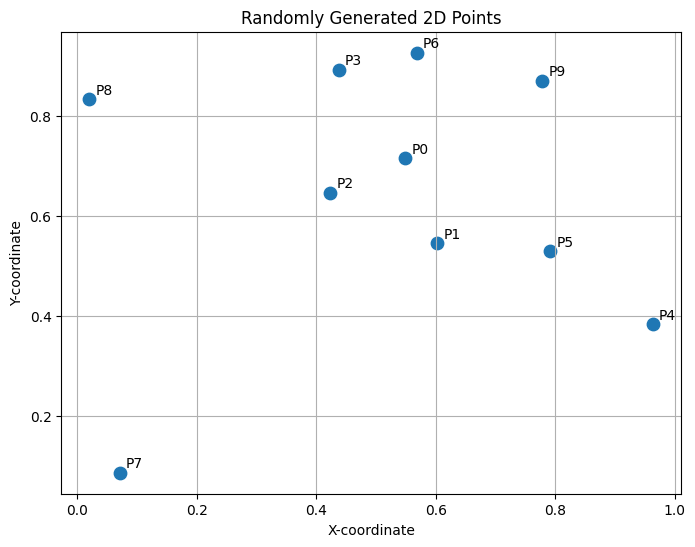

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80)

for i, (x, y) in enumerate(X):
    plt.text(x + 0.01, y + 0.01, f"P{i}") # label each point

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Randomly Generated 2D Points")
plt.grid(True)
plt.show()

In [3]:
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
print("Distance matrix:")
print(D2)

Distance matrix:
[[0.         0.03191478 0.02046653 0.04355307 0.28215654 0.09371163
  0.04464105 0.62273073 0.2932027  0.07656842]
 [0.03191478 0.         0.04228309 0.14761571 0.15631178 0.03596213
  0.14614813 0.49227256 0.42215104 0.13647168]
 [0.02046653 0.04228309 0.         0.06065054 0.36048996 0.14916451
  0.09908191 0.43655809 0.19762743 0.17590053]
 [0.04355307 0.14761571 0.06065054 0.         0.53515638 0.2570941
  0.01816316 0.78181123 0.17769582 0.11646115]
 [0.28215654 0.15631178 0.36048996 0.53515638 0.         0.05071927
  0.45044593 0.88458336 1.09184844 0.27116346]
 [0.09371163 0.03596213 0.14916451 0.2570941  0.05071927 0.
  0.20740521 0.71454947 0.68747133 0.11654506]
 [0.04464105 0.14614813 0.09908191 0.01816316 0.45044593 0.20740521
  0.         0.95004493 0.30875819 0.04723677]
 [0.62273073 0.49227256 0.43655809 0.78181123 0.88458336 0.71454947
  0.95004493 0.         0.55833859 1.11292523]
 [0.2932027  0.42215104 0.19762743 0.17769582 1.09184844 0.68747133
  0.

In [4]:
coordinate_diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("(a) Coordinate diff shape:", coordinate_diff.shape) # (10, 10, 2)

squared_diff = coordinate_diff ** 2
print("(b) Squared diff shape:", squared_diff.shape) # (10, 10, 2)

summed_squared_distances = np.sum(squared_diff, axis=2)
print("(c) Summed shape:", summed_squared_distances.shape) # (10, 10)

(a) Coordinate diff shape: (10, 10, 2)
(b) Squared diff shape: (10, 10, 2)
(c) Summed shape: (10, 10)


In [5]:
diagonal = np.diag(D2)

print("Diagonal of the distance matrix:")
print(diagonal)

print("Are all diagonal values zero?", np.allclose(diagonal, 0))

Diagonal of the distance matrix:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Are all diagonal values zero? True


In [6]:
neighbor_order = np.argsort(D2, axis=1)

print("Neighbor ordering for each point:")
print(neighbor_order)

print("First column:")
print(neighbor_order[:, 0])

Neighbor ordering for each point:
[[0 2 1 3 6 9 5 4 8 7]
 [1 0 5 2 9 6 3 4 8 7]
 [2 0 1 3 6 5 9 8 4 7]
 [3 6 0 2 9 1 8 5 4 7]
 [4 5 1 9 0 2 6 3 7 8]
 [5 1 4 0 9 2 6 3 8 7]
 [6 3 0 9 2 1 5 8 4 7]
 [7 2 1 8 0 5 3 4 6 9]
 [8 3 2 0 6 1 7 9 5 4]
 [9 6 0 3 5 1 2 4 8 7]]
First column:
[0 1 2 3 4 5 6 7 8 9]


In [7]:
K = 2

nearest_using_argsort = neighbor_order[:, 1:K+1]

print("Two nearest neighbors using argsort:")
print(nearest_using_argsort)

Two nearest neighbors using argsort:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]


In [8]:
candidate_indices = np.argpartition(D2, K + 1, axis=1)[:, :K + 1]

# sort only the K+1 candidates by their distances
candidate_distances = np.take_along_axis(D2, candidate_indices, axis=1)
order = np.argsort(candidate_distances, axis=1)
sorted_candidates = np.take_along_axis(candidate_indices, order, axis=1)

nearest_neighbours = sorted_candidates[:, 1:K+1] # drop the point itself

print("K+1 candidate indices:")
print(candidate_indices)

print("Final two nearest neighbours:")
print(nearest_neighbours)

print("Same as argsort?", np.array_equal(nearest_neighbours,
                                           nearest_using_argsort))

K+1 candidate indices:
[[0 2 1]
 [1 0 5]
 [2 0 1]
 [3 6 0]
 [4 5 1]
 [5 1 4]
 [6 3 0]
 [7 2 1]
 [8 3 2]
 [9 6 0]]
Final two nearest neighbours:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Same as argsort? True


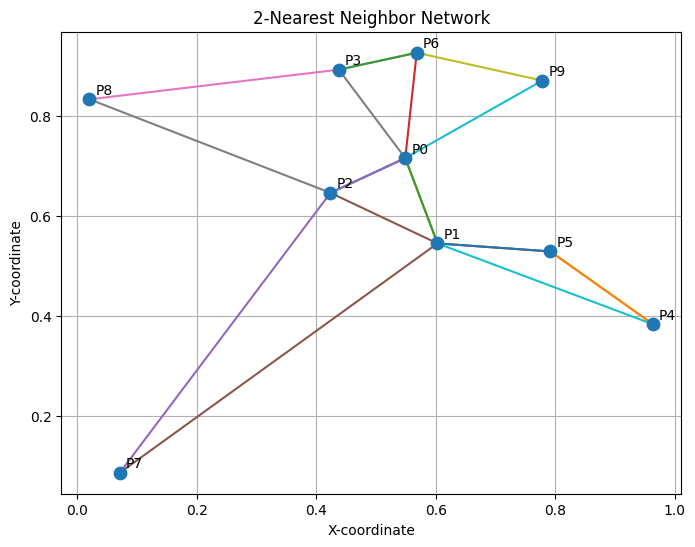

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80, zorder=3)

for i in range(len(X)):
    plt.text(X[i, 0] + 0.01, X[i, 1] + 0.01, f"P{i}")
    for j in nearest_neighbours[i]: # line to each of the 2 NNs
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]])

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest Neighbor Network")
plt.grid(True)
plt.show()

In [13]:
def loop_based_neighbours(X, K=2):
    N = len(X)
    distances = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            difference = X[i] - X[j]
            distances[i, j] = np.sum(difference ** 2)

    neighbours = np.zeros((N, K), dtype=int)

    for i in range(N):
        order = np.argsort(distances[i])
        neighbours[i] = order[1:K+1]

    return neighbours

In [14]:
def vectorised_neighbours(X, K=2):
    D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
                axis=2)

    candidates = np.argpartition(D2, K + 1, axis=1)[:, :K + 1]
    candidate_distances = np.take_along_axis(D2, candidates, axis=1)
    order = np.argsort(candidate_distances, axis=1)
    sorted_candidates = np.take_along_axis(candidates, order, axis=1)

    return sorted_candidates[:, 1:K+1]

In [15]:
v = vectorised_neighbours(X)
l = loop_based_neighbours(X)

print("Vectorized result:")
print(v)

print("Loop-based result:")
print(l)

print("Are both results identical?", np.array_equal(v, l))

Vectorized result:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Loop-based result:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Are both results identical? True


In [ ]:
for N in [100, 1000, 5000]:
    Xn = np.random.rand(N, 2)
    print("N =", N)
    print("Vectorised:")
    %timeit vectorised_neighbours(Xn)
    print("Loop-based:")
    %timeit loop_based_neighbours(Xn)
    print()

N = 100
Vectorised:
1.88 ms ± 685 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Loop-based:
246 ms ± 13 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

N = 1000
Vectorised:
140 ms ± 8.93 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Loop-based:
22.4 s ± 1.91 s per loop (mean ± std. dev. of 7 runs, 1 loop each)

N = 5000
Vectorised:
2.39 s ± 270 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Loop-based:


In [ ]:
from sklearn.neighbors import KDTree

def kdtree_neighbours(X, K=2):
    tree = KDTree(X) # build the tree
    dist, idx = tree.query(X, k=K + 1) # K+1: incl. the point itself
    return idx[:, 1:K+1] # drop the point itself

In [ ]:
# Small dataset (N = 10)
nearest_kdtree = kdtree_neighbours(X)

print(nearest_kdtree)
print("Same as argpartition result?",
      np.array_equal(nearest_kdtree, nearest_neighbours))

# N = 1000 comparison
Xb = np.random.rand(1000, 2)

print(np.array_equal(kdtree_neighbours(Xb),
                     vectorised_neighbours(Xb)))

%timeit vectorised_neighbours(Xb)
%timeit kdtree_neighbours(Xb)